Setup:

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3-8B", dtype="bfloat16")

c:\Users\rajno\Desktop\Thesis\block_sparsity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  9.87it/s]


In [2]:
length = 0
for name, param in model.named_parameters():
    if "proj" in name or "lm_head" in name:
        print(name, param.shape)
        length += 1
print(f"Matrix count: {length}")

model.layers.0.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.0.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.0.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.1.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.1.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.1.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.2.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.2.self_attn.k_proj.weight torch.Size([1024,

In [ ]:
q_proj_weight = model.model.layers[3].self_attn.q_proj.weight
print(q_proj_weight.shape)   # torch.Size([4096, 4096])
print(q_proj_weight)

torch.Size([4096, 4096])
Parameter containing:
tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  ..., -0.0004,  0.0128,  0.0056],
        [ 0.0192,  0.0037, -0.0167,  ...,  0.0115,  0.0078, -0.0008],
        ...,
        [-0.0164,  0.0254,  0.0026,  ...,  0.0089, -0.0062,  0.0029],
        [-0.0457,  0.0171, -0.0064,  ..., -0.0184, -0.0020, -0.0018],
        [-0.0135, -0.0003, -0.0234,  ..., -0.0082,  0.0088,  0.0267]],
       dtype=torch.bfloat16, requires_grad=True)


TODO k_proj check pre 2:4
TODO randomize init pri 2x mid_dim_scale (vysvetliť)
TODO permutácie
TODO permutácie vo find_other (pre 1x2 bloky)

In [4]:
from typing import Literal
import math
import time

from einops import rearrange
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

torch.cuda.empty_cache()
torch.cuda.synchronize()


In [50]:
from matplotlib.colors import ListedColormap

def plot_masks(mask_a, mask_b, mask_type):
    cmap = ListedColormap(["gray", "lime"])
    _, axs = plt.subplots(1, 2, figsize=(8, 4))

    for ax, mask, title in zip(
        axs,
        [mask_a[:16, :16], mask_b[:16, :16]],
        ["mask_a", "mask_b"]
    ):
        _ = ax.imshow(mask, cmap=cmap, vmin=0, vmax=1)

        ax.set_xticks(np.arange(-0.525, 16, 1), minor=True,)
        ax.set_yticks(np.arange(-0.55, 16, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)

        if mask_type == '2to4':
            for x in np.arange(-0.5, 16, 4):
                ax.axvline(x=x, color='deepskyblue', linewidth=1.5)
            for y in np.arange(-0.5, 16, 1):
                ax.axhline(y=y, color='deepskyblue', linewidth=1.5)

        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [6]:
q_proj_weight = q_proj_weight.cuda()
print(q_proj_weight.device)
print(q_proj_weight.dtype)

cuda:0
torch.bfloat16


Mask functions:

In [7]:
def mag_prune(W, sp=0.5):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return W * mask

In [8]:
def _mag_prune_mask(W, sp=0.6):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return mask

In [9]:
# TODO optimizations
def _block_mask(
    W_hat: torch.Tensor, 
    U: torch.Tensor, 
    bsparsity: float,
    rows: int, cols: int
) -> torch.Tensor:
    # W_hat... a 4096*4096 matrix
    # we take 2x2 blocks and if norm is below thres, we set the whole block to 0

    # get the 2x2 blocks and calculate norms
    blocks = rearrange((W_hat+U).abs(), '(h bh) (w bw) -> h w bh bw', bh=rows, bw=cols)
    block_norms = blocks.norm(dim=(-2, -1), p=2)

    # expand back to 4096*4096
    expanded = block_norms.repeat_interleave(rows, dim=0).repeat_interleave(cols, dim=1)

    # construct the mask
    flat = expanded.abs().flatten()
    n = flat.numel()
    k = max(1, int(bsparsity * n))
    thres = torch.kthvalue(flat, k).values
    # thres = torch.quantile(expanded.abs().flatten(), bsparsity)
    mask = (expanded.abs() > abs(thres.item()))

    # del flat
    del blocks, block_norms, expanded, flat
    return mask

In [10]:
def default_block_mask(W_hat, U, bsparsity):
    return _block_mask(W_hat, U, bsparsity, 2, 2)

In [11]:
def _get_mask_2_to_4(
    W_hat: torch.Tensor, 
    U: torch.Tensor,
    bsparsity: float,
    transpose: bool = True
) -> torch.Tensor:

    W_U_sum = W_hat + U
    if transpose:
        W_U_sum = W_U_sum.T
    rows = W_U_sum.shape[0]
    thres = int(W_U_sum.numel() * (1 - bsparsity)) # 16% or 24% of elements

    # create groups of 4 and sort the 4 elements in each one
    W_U_sum_grouped = W_U_sum.reshape(rows, -1, 4)
    g_sorted_elements, _ = W_U_sum_grouped.abs().sort(dim=-1, descending=True)
    
    # calculate norms of [top two elements] in each group
    # then sort groups according to the result
    # (we use norm as that performed best in usual block sparsity)
    top2_sums = g_sorted_elements[:, :, :2].norm(dim=-1, p=2)
    _, best_group_ids = top2_sums.flatten().sort(descending=True)
    
    group_take_count = (thres // 4) * 2
    # each group contains 4 elements, so we divide by 4, but 2:4 will be applied,
    # so we multiply by 2 to get the desired sparsity

    # group-wise mask
    # we get locations of groups where the calculated norms are the highest
    # we keep these locations in the mask
    all_groups_count = W_U_sum_grouped.shape[1]
    g_mask = torch.zeros(rows * all_groups_count, dtype=torch.bool, device=W_U_sum.device)
    g_mask[best_group_ids[:group_take_count]] = True
    g_mask = g_mask.reshape(rows, all_groups_count)

    # apply 2:4 in selected groups -> now we get back to 16%/24% sparsity
    # we select top two elements in absolute value as they contribute the most to the norm
    _, ids = W_U_sum_grouped.abs().topk(2, dim=-1, sorted=False)
    mask = torch.zeros_like(W_U_sum_grouped, dtype=torch.bool)
    mask = mask.scatter(-1, ids, True)
    mask = mask & g_mask.unsqueeze(-1) # add dim to zero out the remaining groups
    mask = mask.reshape(rows, -1)
    
    del W_U_sum_grouped, g_sorted_elements, top2_sums, g_mask
    if transpose:
        mask = mask.T
    return mask

Factorization functions:

In [12]:
# penalty factor
RHO = 1

In [51]:
# inner loop of the ||W-AB||_2 minization algorithm
# ADMM is performed for m (iters) iterations
def find_other2(X, W, nnz, Z, U, mask_type, alt=False, reg=0, rho_start=0.03, iters=5, prune_iters=2):
    # Z_0 = identity
    # U_0 = zero matrix
    # X can be:
    # -> A, when we're solving for B (Z) and U_b (U)
    # -> B, when we're solving for A (Z) and U_a (U)

    # normalization with diag. reg.
    XTX = X.T.matmul(X)
    norm2 = torch.diag(XTX).sqrt() + 1e-8
    An = X / norm2
    XTX = An.T.matmul(An)
    XTX += torch.diag(torch.ones_like(XTX.diag())) * XTX.diag().mean() * reg
    
    rho = RHO
    XTW = An.T.matmul(W)
    XTX_inv = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho)
    XTX_inv2 = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho_start)
    
    U = U * norm2.unsqueeze(1)
    Z = Z * norm2.unsqueeze(1)
    
    W_hat = XTX_inv2.matmul(XTW + rho_start*(Z-U))
    bsparsity = min(0.99, 1 - nnz/W_hat.numel()) # 0.76 or 0.84
    
    for itt in range(iters):            
        if itt < prune_iters:
            if not mask_type:
                mask = _mag_prune_mask(W_hat+U, bsparsity)

            if mask_type == 'blocks':
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=2)

            if mask_type == 'blocks_alt' and not alt:
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=1)
            if mask_type == 'blocks_alt' and alt:
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=1, cols=2)
            # if mask_type == 'blocks_alt':
            #     mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=1)

            if mask_type == '2to4' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=True)
            if mask_type == '2to4' and alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=False)

            if mask_type == 'hybrid' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity)
            if mask_type == 'hybrid' and alt:
                mask = _mag_prune_mask(W_hat+U, bsparsity)

        # ADMM iterations
        Z = mask * (W_hat + U)
        U = U + (W_hat - Z)    
        W_hat = XTX_inv.matmul(XTW + rho*(Z-U))
    
    return (Z) / norm2.unsqueeze(1), U / norm2.unsqueeze(1), mask.cpu()

In [52]:
# this finds AB such that ||W-AB||_2 is minimized
# XX is here for LLMs only
def _factorize(W, XX, mask_type, bsp=0.16, sp=0.4, mid_dim_scale=1, iters=40):
    transpose = False
    if W.shape[0] > W.shape[1]: # > ???
        W = W.T
        transpose = True
    
    nza = int(W.shape[0]*W.shape[1] * bsp)
    nzb = int(W.numel() * sp - nza)

    # "for the pruning of LLMs, we found that it is better
    # to project the weight matrix multiplied
    # by input feature norm"
    norm = XX.diag().sqrt() + 1e-8
    # norm = torch.ones_like(norm)               # for vision models
    Wn = W * norm

    
    # solve the projection problem
    if mid_dim_scale == 1:
        A = torch.eye(W.shape[0], device=W.device)  # identity
        B = mag_prune(Wn, (1 - nzb/2/W.numel()))    # magnitude pruning of input
    else:
        A = torch.eye(n=W.shape[0], m=int(mid_dim_scale*W.shape[0]), device=W.device)  # identity
        B = torch.eye(n=int(mid_dim_scale*W.shape[0]), m=W.shape[0], device=W.device)  # identity

    U_a = torch.zeros_like(A)
    U_b = torch.zeros_like(B)

    alt = False
    if mask_type in ['blocks_alt', 'hybrid', '2to4']:
        alt = True
    
    # inner loop
    for itt in range(iters):
        rho_start = min(1.0, itt / (iters-3))**3 # annealing
        
        A, U_a, mask_a = (x.T for x in find_other2(
                       B.T, Wn.T, nza, A.T, U_a.T, reg=1e-2, rho_start=rho_start, mask_type=mask_type
                    )
                 )
        B, U_b, mask_b = find_other2(
                    A, Wn, nzb, B, U_b, reg=1e-2, rho_start=rho_start, mask_type=mask_type, alt=alt
                 )
        
        if itt == iters - 1:
            plot_masks(mask_a, mask_b, mask_type)
        
    if transpose:
        return ((A / norm).matmul(B)).T, B.T, (A / norm).T
    else:
        return A.matmul(B / norm), A, B / norm

Test functions:

In [15]:
@torch.no_grad()
def test_mag_prune(sp: int):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight.to(dtype=torch.float32)
    identity = torch.eye(q_proj_weight.shape[0], device="cuda")
    prod = mag_prune(matrix, sp=sp)

    frobenius = torch.norm(matrix - prod, p='fro')
    print(f"Frobenius norm: {frobenius.item()}")

    prod = prod.cpu()
    print(f"AB: {prod}")
    print(f"Input matrix was: {matrix}")

    n_ab = matrix.size(dim=0)
    m_ab = matrix.size(dim=1)
    nz_count_AB = torch.count_nonzero(prod).item()

    del matrix, identity
    torch.cuda.empty_cache()

    print(f"AB has {nz_count_AB} non-zero entries ({round(nz_count_AB/(n_ab*m_ab)*100, 1)}%)")

    return float(frobenius.item())


In [16]:
@torch.no_grad()
def test_double_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale, 
                       mask_type: None | Literal['blocks', 'blocks_alt', '2to4', 'hybrid'] = None):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight.to(dtype=torch.float32)
    identity = torch.eye(q_proj_weight.shape[0], device="cuda")
    prod, A, B = _factorize(matrix, 
                            identity, 
                            bsp = (1-b_bias)*total_sp, 
                            sp = total_sp, 
                            mid_dim_scale = mid_dim_scale,
                            mask_type = mask_type
    )

    frobenius = torch.norm(prod - matrix, p='fro')
    print(f"Frobenius norm: {frobenius.item()}")

    prod = prod.cpu()
    A = A.cpu()
    B = B.cpu()

    nz_count_A = torch.count_nonzero(A).item()
    nz_count_B = torch.count_nonzero(B).item()

    print(f"A: {A[:4, :4]}")
    print(f"B: {B[:4, :4]}")
    print(B.size())
    print(f"AB: {prod}")
    print(f"Input matrix was: {matrix}")

    n_a = A.size(dim=0)
    m_a = A.size(dim=1)
    n_b = B.size(dim=0)
    m_b = B.size(dim=1)

    del A, B, matrix, identity
    torch.cuda.empty_cache()
    
    print(f"A has {nz_count_A} non-zero entries ({round(nz_count_A/(n_a*m_a)*100, 1)}%)")
    print(f"B has {nz_count_B} non-zero entries ({round(nz_count_B/(n_b*m_b)*100, 1)}%)")

    return float(frobenius.item())


In [17]:
@torch.no_grad()
def test_double_block_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale):
    return test_double_sparse(total_sp, b_bias, mid_dim_scale, mask_type='blocks')

In [18]:

@torch.no_grad()
def test_2to4_A_B(sp=0.25, 
                  mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='2to4')

In [19]:
@torch.no_grad()
def test_1x2_2x1(sp=0.25, 
                 mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='blocks_alt')

In [20]:
@torch.no_grad()
def test_hybrid(asp=0.25, bsp=0.25):
    return test_double_sparse(total_sp=asp+bsp, b_bias=bsp/(asp+bsp), mid_dim_scale=1, mask_type='hybrid')


Tests:

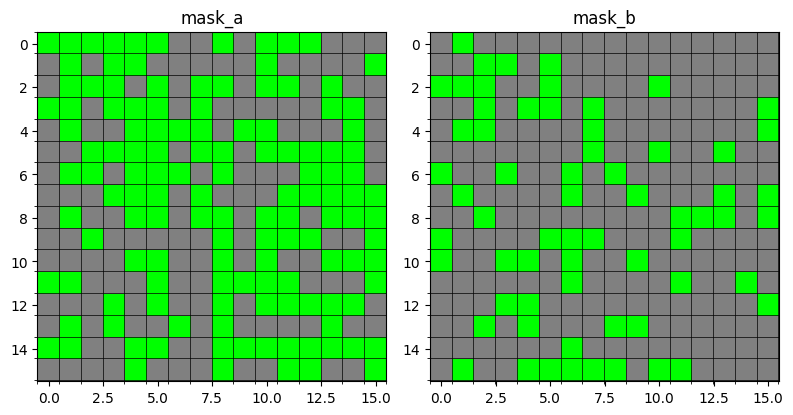

Frobenius norm: 7.480566501617432
A: tensor([[ 0.7614,  0.5842,  0.7607, -0.5072],
        [ 0.0000,  0.9997,  0.0000, -0.0720],
        [ 0.0000,  0.1951,  1.3975, -0.2092],
        [-0.1454, -0.3809, -0.0000,  1.0517]])
B: tensor([[ 0.0000, -0.0025, -0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0034,  0.0047],
        [ 0.0052, -0.0014, -0.0037,  0.0000],
        [ 0.0000,  0.0000, -0.0038, -0.0000]])
torch.Size([4096, 4096])
AB: tensor([[ 0.0093,  0.0064,  0.0004,  ...,  0.0168,  0.0021,  0.0092],
        [ 0.0088,  0.0109,  0.0127,  ..., -0.0015,  0.0137,  0.0013],
        [ 0.0173,  0.0032, -0.0135,  ...,  0.0090,  0.0046,  0.0028],
        ...,
        [-0.0176,  0.0235,  0.0025,  ...,  0.0078, -0.0013, -0.0002],
        [-0.0421,  0.0146, -0.0058,  ..., -0.0193,  0.0020,  0.0017],
        [-0.0119,  0.0014, -0.0211,  ..., -0.0060,  0.0102,  0.0272]])
Input matrix was: tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  ..

In [66]:
a = test_double_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

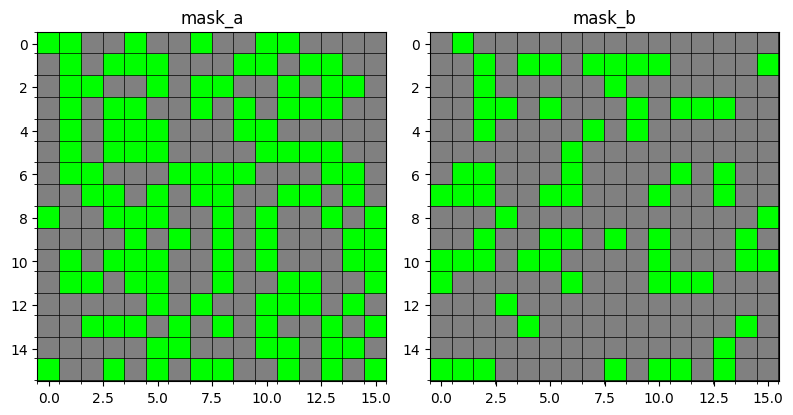

Frobenius norm: 8.738487243652344
A: tensor([[ 1.0600,  0.7658,  0.0000, -0.0000],
        [-0.0000,  1.1176, -0.0000, -0.3523],
        [ 0.0000,  0.0989,  0.7080,  0.0000],
        [-0.0000, -0.5422, -0.0000,  1.1635]])
B: tensor([[-0.0000, -0.0043, -0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0139, -0.0000],
        [ 0.0000, -0.0000,  0.0031, -0.0000],
        [ 0.0000,  0.0000,  0.0033, -0.0060]])
torch.Size([4096, 4096])
AB: tensor([[ 7.8240e-03,  6.5280e-03, -1.0356e-04,  ...,  1.1798e-02,
          4.3102e-03,  1.0922e-02],
        [ 9.9870e-03,  1.2248e-02,  1.6642e-02,  ...,  2.5668e-03,
          1.3665e-02,  2.1691e-03],
        [ 1.6432e-02,  7.6778e-03, -1.3050e-02,  ...,  1.3550e-02,
          6.1543e-03,  5.2372e-04],
        ...,
        [-1.7754e-02,  2.6743e-02, -2.0474e-03,  ...,  1.0621e-02,
         -4.9137e-03, -4.2523e-04],
        [-4.8011e-02,  2.1892e-02, -7.0773e-03,  ..., -1.9571e-02,
         -7.1789e-04, -9.4904e-04],
        [-1.4935e-02, -6.9685e-05

In [22]:
b = test_hybrid(asp=0.25, bsp=0.25)

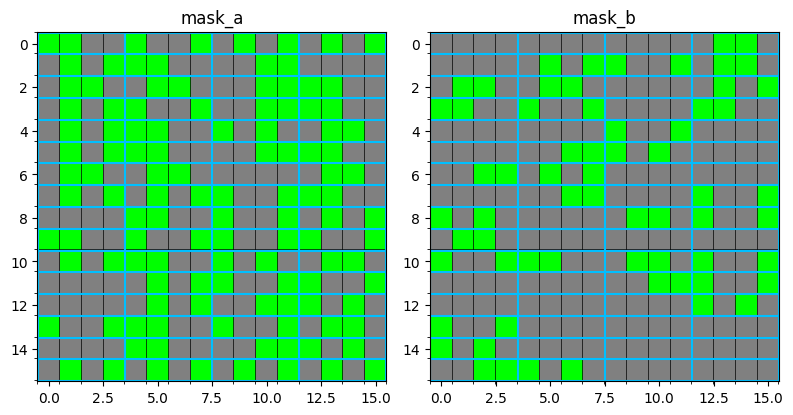

Frobenius norm: 10.353509902954102
A: tensor([[ 1.5044,  0.7699,  0.0000, -0.0000],
        [ 0.0000,  1.3557, -0.0000, -0.3593],
        [ 0.0000,  0.1464,  1.2774,  0.0000],
        [ 0.0000, -0.5670,  0.0000,  1.5050]])
B: tensor([[ 0.0000, -0.0000,  0.0000, -0.0000],
        [-0.0000,  0.0000,  0.0000,  0.0000],
        [-0.0000, -0.0018,  0.0008, -0.0000],
        [ 0.0048, -0.0022, -0.0000,  0.0000]])
torch.Size([4096, 4096])
AB: tensor([[ 7.5025e-03,  9.9250e-03, -2.6587e-03,  ...,  9.5445e-03,
          6.0782e-05,  6.0272e-03],
        [ 9.0468e-03,  1.4496e-02,  1.1908e-02,  ...,  1.8457e-03,
          1.4020e-02,  3.6085e-03],
        [ 1.7277e-02,  1.9207e-03, -1.6895e-02,  ...,  7.0101e-03,
          4.1741e-03, -2.6822e-03],
        ...,
        [-1.8974e-02,  2.6499e-02, -1.5606e-03,  ...,  1.3562e-02,
         -5.4085e-03,  4.2550e-03],
        [-4.3813e-02,  2.0090e-02, -5.2420e-03,  ..., -1.9771e-02,
         -5.1004e-03, -3.3091e-04],
        [-1.6272e-02, -5.0759e-0

In [23]:
c = test_2to4_A_B(sp=0.25, mid_dim_scale=1)

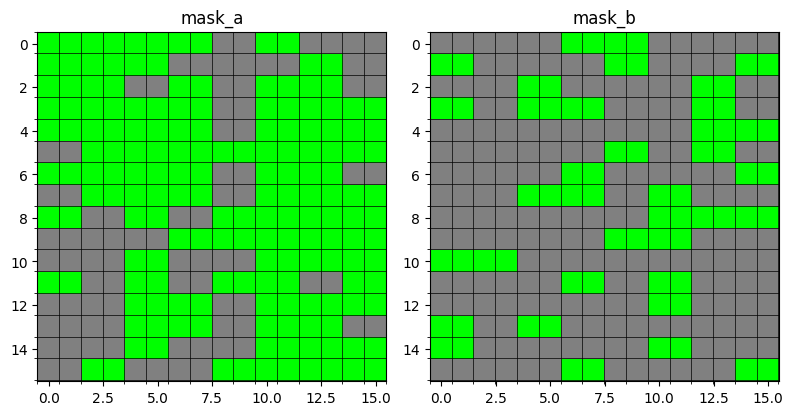

Frobenius norm: 12.733384132385254
A: tensor([[ 1.6241,  0.8888,  0.8442, -0.4846],
        [ 0.5554,  1.3223,  0.3568, -0.4185],
        [ 0.8008,  0.3257,  0.9268,  0.0425],
        [-0.7482, -0.6274, -0.1500,  1.3497]])
B: tensor([[ 0.0000, -0.0000, -0.0000,  0.0000],
        [ 0.0055,  0.0031, -0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0000, -0.0000],
        [ 0.0063, -0.0007,  0.0000,  0.0000]])
torch.Size([4096, 4096])
AB: tensor([[ 0.0076,  0.0052,  0.0015,  ...,  0.0134,  0.0103,  0.0041],
        [ 0.0113,  0.0164,  0.0101,  ...,  0.0007,  0.0124,  0.0067],
        [ 0.0144, -0.0033, -0.0138,  ...,  0.0064,  0.0049,  0.0013],
        ...,
        [-0.0157,  0.0263, -0.0016,  ...,  0.0123, -0.0065,  0.0044],
        [-0.0474,  0.0195, -0.0072,  ..., -0.0168,  0.0023,  0.0035],
        [-0.0127,  0.0022, -0.0205,  ..., -0.0084,  0.0029,  0.0270]])
Input matrix was: tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  .

In [24]:
d = test_1x2_2x1(sp=0.25, mid_dim_scale=1)

In [25]:
e = test_mag_prune(sp=0.5)

Frobenius norm: 16.52720832824707
AB: tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0166,  0.0000,  0.0000],
        [ 0.0125,  0.0153,  0.0129,  ..., -0.0000,  0.0128,  0.0000],
        [ 0.0192,  0.0000, -0.0167,  ...,  0.0115,  0.0000, -0.0000],
        ...,
        [-0.0164,  0.0254,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
        [-0.0457,  0.0171, -0.0000,  ..., -0.0184, -0.0000, -0.0000],
        [-0.0135, -0.0000, -0.0234,  ..., -0.0000,  0.0000,  0.0267]])
Input matrix was: tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  ..., -0.0004,  0.0128,  0.0056],
        [ 0.0192,  0.0037, -0.0167,  ...,  0.0115,  0.0078, -0.0008],
        ...,
        [-0.0164,  0.0254,  0.0026,  ...,  0.0089, -0.0062,  0.0029],
        [-0.0457,  0.0171, -0.0064,  ..., -0.0184, -0.0020, -0.0018],
        [-0.0135, -0.0003, -0.0234,  ..., -0.0082,  0.0088,  0.0267]],
       device='cuda:0')
AB has 8369617 non-zero entries (49.9%)


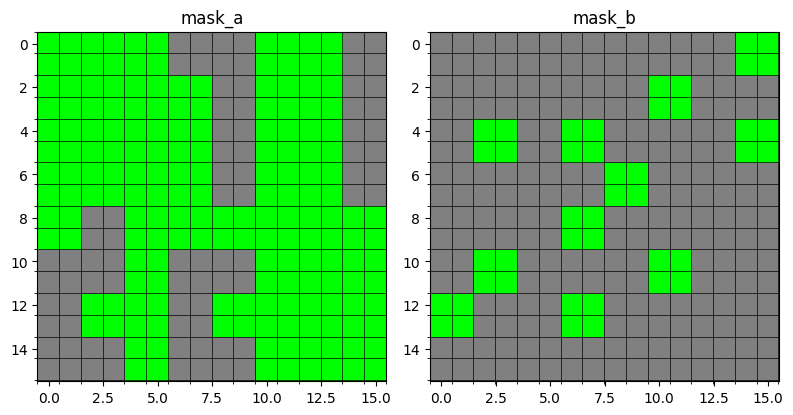

Frobenius norm: 17.682727813720703
A: tensor([[ 1.1867,  0.6045,  1.1627, -0.9297],
        [ 0.7226,  1.3057, -0.0346, -0.5579],
        [ 0.5101,  0.1600,  1.4791, -0.5012],
        [-0.7389, -0.5508, -0.5954,  1.7335]])
B: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., -0., -0., -0.],
        [0., -0., -0., 0.]])
torch.Size([4096, 4096])
AB: tensor([[ 3.6910e-03,  2.7809e-03, -9.6076e-03,  ...,  9.3423e-03,
          2.4723e-03,  1.1402e-02],
        [ 6.4956e-03,  5.6373e-03,  8.5923e-03,  ...,  6.4294e-03,
          5.9279e-03,  3.3495e-03],
        [ 8.6339e-03,  6.4824e-03, -7.7718e-03,  ...,  5.1257e-03,
          2.0358e-03,  3.7864e-03],
        ...,
        [-1.2989e-02,  2.1549e-02, -2.1307e-04,  ...,  6.8077e-03,
          1.1620e-03,  7.6887e-03],
        [-4.7292e-02,  1.5027e-02,  3.5368e-03,  ..., -1.7375e-02,
         -1.5922e-05, -1.2262e-03],
        [-1.5739e-02, -3.4385e-03, -1.7310e-02,  ..., -1.4911e-02,
          7.1589e-03,  2.3365e-02]])
Inp

In [26]:
f = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

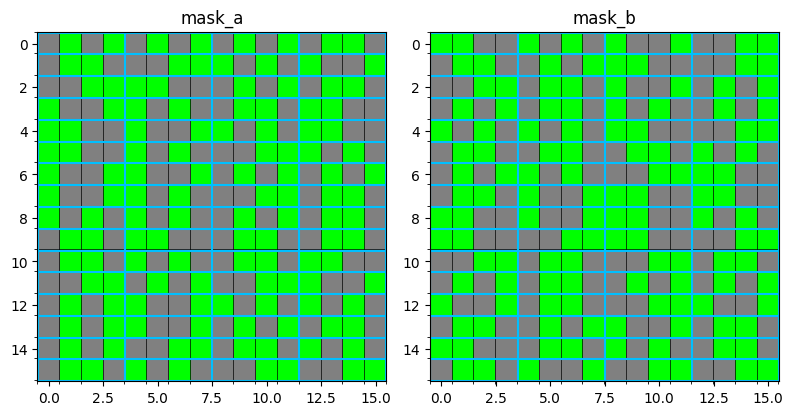

Frobenius norm: 18.121423721313477
A: tensor([[ 0.0000,  0.0049, -0.0000,  0.0076],
        [ 0.0000,  0.0063,  0.0138, -0.0000],
        [ 0.0000,  0.0000, -0.0080, -0.0115],
        [ 0.0295, -0.0000,  0.0000, -0.0145]])
B: tensor([[ 0.7368, -0.0198, -0.0000, -0.0000],
        [ 0.0000,  0.7490,  0.0039, -0.0000],
        [-0.0000, -0.0000,  0.7482,  0.0155],
        [-0.0000,  0.0334, -0.0000,  0.7724]])
torch.Size([2048, 4096])
AB: tensor([[ 4.1058e-03,  2.5587e-03, -7.6871e-03,  ...,  7.2705e-03,
          7.8929e-03,  4.0276e-03],
        [ 1.2032e-02,  1.5245e-03,  9.1764e-03,  ..., -5.1877e-03,
          7.4161e-03, -1.3871e-03],
        [ 1.2529e-02,  4.0119e-04, -1.7044e-02,  ...,  9.3647e-03,
         -1.4613e-03, -5.3960e-04],
        ...,
        [-1.9503e-02,  2.2280e-02,  4.1862e-03,  ...,  8.6449e-03,
          1.4621e-04, -1.3371e-03],
        [-4.3531e-02,  6.9333e-03, -7.5716e-04,  ..., -2.1920e-02,
          4.9375e-05, -3.1470e-03],
        [-1.1860e-02, -4.5559e-0

In [27]:
g = test_2to4_A_B(sp=0.5, mid_dim_scale=0.5)

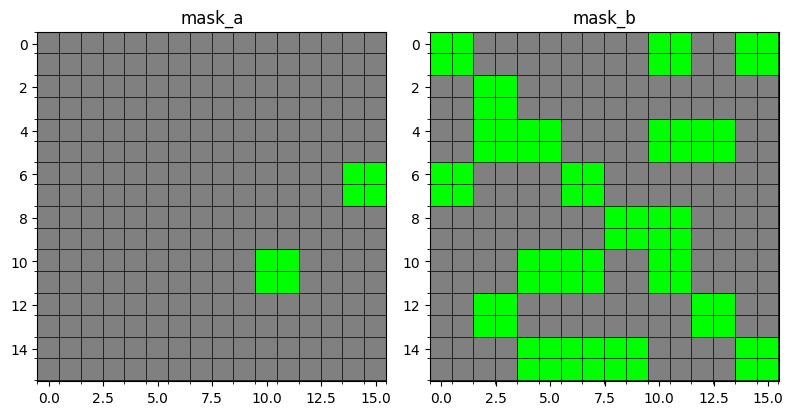

Frobenius norm: 18.269527435302734
A: tensor([[-0., 0., 0., 0.],
        [-0., 0., 0., 0.],
        [0., 0., 0., -0.],
        [-0., -0., 0., -0.]])
B: tensor([[ 0.4073, -0.0261, -0.0000,  0.0000],
        [-0.0353,  0.3764, -0.0000, -0.0000],
        [ 0.0000, -0.0000,  0.3573, -0.0449],
        [ 0.0000,  0.0000,  0.0534,  0.3916]])
torch.Size([8192, 4096])
AB: tensor([[ 0.0034,  0.0039, -0.0025,  ...,  0.0138,  0.0072,  0.0085],
        [ 0.0048,  0.0115,  0.0074,  ...,  0.0043,  0.0069,  0.0105],
        [ 0.0079,  0.0052, -0.0096,  ...,  0.0128,  0.0055, -0.0025],
        ...,
        [-0.0216,  0.0244,  0.0066,  ...,  0.0079, -0.0020, -0.0016],
        [-0.0342,  0.0126,  0.0012,  ..., -0.0235,  0.0046, -0.0018],
        [-0.0186,  0.0021, -0.0270,  ..., -0.0116,  0.0130,  0.0211]])
Input matrix was: tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  ..., -0.0004,  0.0128,  0.0056],
        [ 0.0192,  0.0037, -0.0167,  ..., 

In [30]:
h = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

Output:

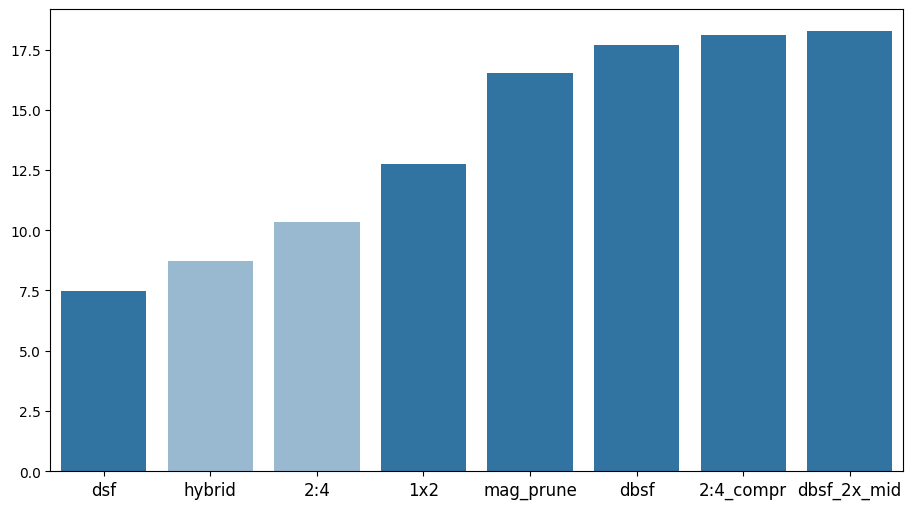

In [67]:
import seaborn as sns
sns.reset_orig()

from matplotlib import rcParams
rcParams['figure.figsize'] = 11, 6

outputs = {"dsf": a,
           "hybrid": b, 
           "2:4": c,
           "1x2": d,
           "mag_prune": e,
           "dbsf": f,
           "2:4_compr": g,
           "dbsf_2x_mid": h}
alpha = [1, 0.5, 0.5, 1, 1, 1, 1, 1]

bars = sns.barplot(x = outputs.keys(), y = outputs.values())
bars.tick_params(axis='x', labelsize=12)
for bar, a in zip(bars.containers[0], alpha):
    bar.set_alpha(a)

Cleanup:

In [29]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()